In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [3]:
#load dataset
df=pd.read_excel("Online Retail.xlsx")

#display first five records
print(df.head())
#dataset info
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [7]:
#removing customers with mising IDs
df=df.dropna(subset=["CustomerID"])
#Removing cancelled invoices.Keep invoices who Invoice no dose Not start with :C"
df=df[~df["InvoiceNo"].astype(str).str.startswith("C")]
#Removing incalid quantities and prices
df=df[df["Quantity"]>0]
df=df[df["UnitPrice"]>0]
#creating total amount=quantity  x unitprice
df["TotalAmount"]=df["Quantity"] * df["UnitPrice"]

In [21]:
#dimension of the dataframe provide two values:the no of rows and the no of columns
df.shape
#display the 1st 5 records
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
#create customer level data
#customer level aggregation
customer_data=df.groupby("CustomerID").agg(
    TotalSpend=("TotalAmount","sum"),
    TotalQuantity=("Quantity","sum"),
    NumberOfTransactions=("InvoiceNo","nunique"),
    NumberOfProducts=("StockCode","nunique"),
    AverageOrderValue=("TotalAmount","mean"),
    Country=("Country","first")
).reset_index()
customer_data.head()# * "print" optional

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,NumberOfProducts,AverageOrderValue,Country
0,12346.0,77183.60,74215,1,1,77183.600000,United Kingdom
1,12347.0,4310.00,2458,7,103,23.681319,Iceland
2,12348.0,1797.24,2341,4,22,57.975484,Finland
3,12349.0,1757.55,631,1,73,24.076027,Italy
4,12350.0,334.40,197,1,17,19.670588,Norway


In [20]:
customer_data["Segment"]=pd.qcut(
    customer_data["TotalSpend"],
    q=3,
    labels=["low Values","Medium Values","High Values"]
)
print(customer_data["Segment"].value_counts())


Segment
low Values       1446
Medium Values    1446
High Values      1446
Name: count, dtype: int64


In [23]:
features=[
    "TotalQuantity",
    "NumberOfTransactions",
    "NumberOfProducts",
    "AverageOrderValue"
]
x=customer_data[features]
y=customer_data["Segment"]

In [42]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

id3_model=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=4
)
id3_model.fit(x_train,y_train)
y_pred=id3_model.predict(x_test)
print("Predictions")
print(y_pred[:20])

Predictions
['Medium Values' 'low Values' 'Medium Values' 'Medium Values'
 'Medium Values' 'High Values' 'Medium Values' 'High Values' 'High Values'
 'low Values' 'Medium Values' 'low Values' 'High Values' 'High Values'
 'High Values' 'High Values' 'Medium Values' 'Medium Values' 'low Values'
 'Medium Values']


In [36]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy.",accuracy)
print("\nClassificaton Report:")
print(classification_report(y_test,y_pred))

Accuracy. 0.8536866359447005

Classificaton Report:
               precision    recall  f1-score   support

  High Values       0.89      0.88      0.89       289
Medium Values       0.77      0.82      0.79       289
   low Values       0.90      0.86      0.88       290

     accuracy                           0.85       868
    macro avg       0.86      0.85      0.85       868
 weighted avg       0.86      0.85      0.85       868



In [37]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))


Confusion Matrix
[[255  32   2]
 [ 28 236  25]
 [  2  38 250]]


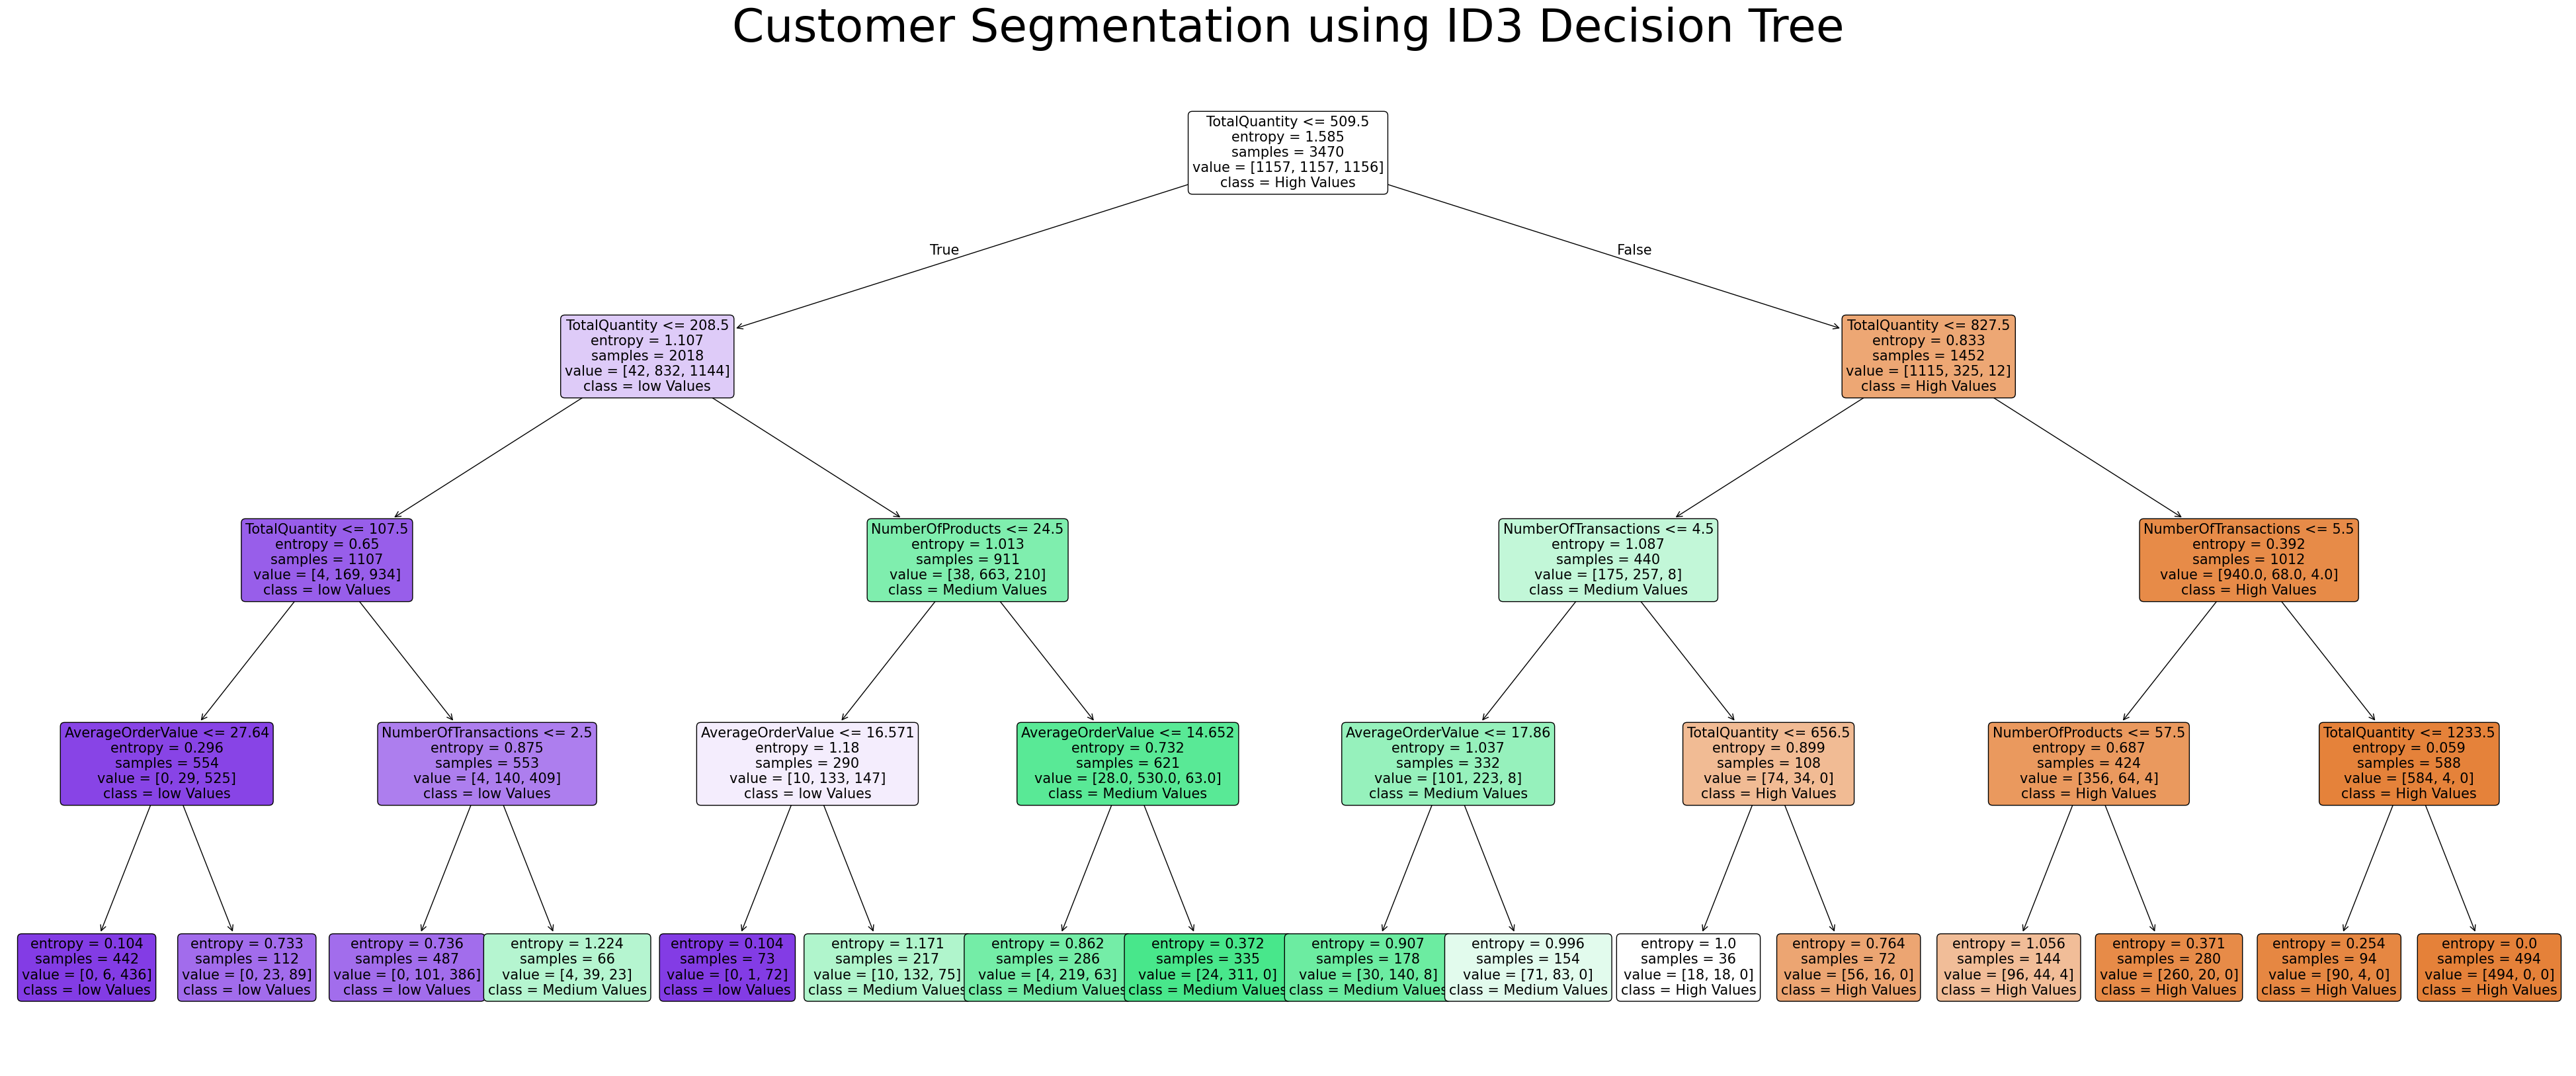

In [69]:
importance=pd.DataFrame({
    "Feature":features,
    "Importance":id3_model.feature_importances_
})
importance_sorted =importance.sort_values(
    "Importance",
    ascending=True
)
#decison tree
plt.figure(figsize=(50,20))
plot_tree(
    id3_model,
    feature_names=features,
    class_names=id3_model.classes_,
    filled=True,
    rounded=True,
    proportion=False,
    fontsize=15
)
plt.title("Customer Segmentation using ID3 Decision Tree",fontsize=50)
plt.show()

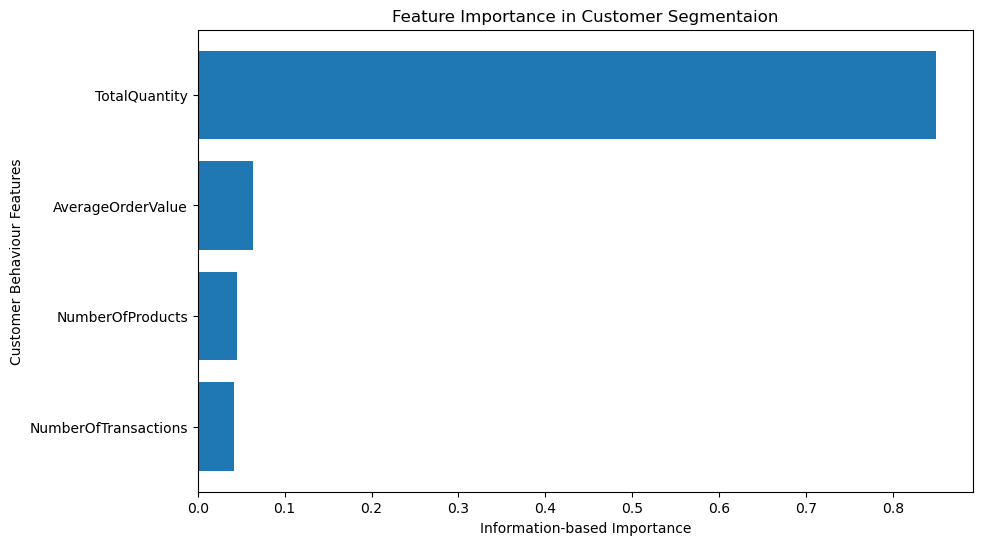

In [48]:
#feature importance
plt.figure(figsize=(10,6))
importance_sorted=importance.sort_values(
    "Importance",
    ascending=True
)
plt.barh(
    importance_sorted["Feature"],
    importance_sorted["Importance"]
)
plt.xlabel("Information-based Importance")
plt.ylabel("Customer Behaviour Features")
plt.title("Feature Importance in Customer Segmentaion")
plt.show()